In [122]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# dx = 1 km; Np = 1M; Nt = 5 min
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_1e6.nc') #***
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_1e6.nc') #***
res='1km'
Np_str='1e6'

# # dx = 1 km; Np = 1M; Nt = 1 min
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_1e6_1min.nc') #***
# parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_1e6_1min.nc') #***
# res='1km'
# Np_str='1e6'


# dx = 250 m
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

In [123]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [90]:
# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}_5min.h5'
# in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}_1min.h5'
with h5py.File(in_file, 'r') as f:
    # Load the dataset by its name
    A_g = f['A_g'][:]
    A_c = f['A_c'][:]

    W = f['W'][:]
    
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

# #Making Time Matrix
Nt=len(data['time'])
T = np.broadcast_to(np.arange(Nt)[:, None], A_c.shape)  # shape: (Nt, p)

In [91]:
#READING BACK IN
mins_thresh=5
dir3=dir+f'Project_Algorithms/Entrainment/processed_binary_arrays_'+str(mins_thresh)+f'mins_{res}_{Np_str}.h5'
# dir3=dir+f'Project_Algorithms/Entrainment/processed_binary_arrays_'+str(mins_thresh)+f'mins_{res}_{Np_str}_1min.h5'
with h5py.File(dir3, 'r') as h5file:
    A_g_Processed = h5file['A_g_Processed'][:]
    A_c_Processed = h5file['A_c_Processed'][:]

In [ ]:
#############################################################################
#############################################################################

In [ ]:
def VMF3d(A, T, Z, Y, X):
    start_time = time.time()
    """
    Function to compute 3D Mass Flux and update result array based on provided inputs.
    
    Returns a 3D (t,z,y,x) array containing the sum of the D array represented by parcels in cloudy updrafts by 1.
    The finally array is then ordered by the appropiate index using the np.add.at function.
    
    Parameters:
    - A: The (t,p) lagrangian binary array.
    - T: The (t,p) lagrangian time index array.
    - Z: The (t,p) Lagrangian z index array.
    - Y: The (t,p) Lagrangian y index array.
    - X: The (t,p) Lagrangian x index array.

    """
    # Compute the difference between neighboring elements along the first axis
    D = A * W
    
    # # Update D for entrainment/detrainment
    # if type=='e':
    #     D[D <= 0] = 0
    # elif type=='d':
    #     D[D >= 0] = 0
    
    # Initialize time and vertical dimension arrays
    Nt = len(data['time']); Nz = len(data['zh']); Ny = len(data['yh']); Nx = len(data['xh'])
    
    # Initialize result array
    result = np.zeros((Nt, Nz, Ny, Nx))
    
    # Use np.add.at to accumulate values in the result array
    np.add.at(result, (T, Z, Y, X), D)
    
    end_time = time.time()
    print(f"Execution time: {(end_time - start_time)} seconds")
    return result

In [ ]:
#TURN PROCESSING ON OR OFF
PROCESSING=False
PROCESSING=True

# Set A based on PROCESSING state
print('Calculating 3D VMF for General Updrafts')
A = A_g if (PROCESSING==False) else A_g_Processed
profile_array_VMF_g = VMF3d(A, T, Z, Y, X)


# Set A for the second block
print('Calculating 3D VMF for Cloudy Updrafts')
A = A_c if (PROCESSING==False) else A_c_Processed
profile_array_VMF_c = VMF3d(A, T, Z, Y, X)


#SAVING
if PROCESSING==False:
    # dir3=dir+f'Project_Algorithms/Entrainment/3D_VMF_profiles_{res}_{Np_str}.h5'
    dir3=dir+f'Project_Algorithms/Entrainment/3D_VMF_profiles_{res}_{Np_str}_1min.h5'
if PROCESSING==True:
    # dir3=dir+f'Project_Algorithms/Entrainment/3D_VMF_profiles_PREPROCESSING_{res}_{Np_str}.h5'
    dir3=dir+f'Project_Algorithms/Entrainment/3D_VMF_profiles_PREPROCESSING_{res}_{Np_str}_1min.h5'
with h5py.File(dir3, "w") as h5f:
    h5f.create_dataset("profile_array_VMF_g", data=profile_array_VMF_g)
    h5f.create_dataset("profile_array_VMF_c", data=profile_array_VMF_c)
print('done')

In [ ]:
########################################################
########################################################
#PLOTTING

In [124]:
#constants
Cp=1004 #Jkg-1K-1
Cv=717 #Jkg-1K-1
Rd=Cp-Cv #Jkg-1K-1
eps=0.608

Lx=(data['xf'][-1].item()-data['xf'][0].item())*1000 #x length (m)
Ly=(data['yf'][-1].item()-data['yf'][0].item())*1000 #y length (m)
Np=len(parcel['xh']) #number of lagrangian parcles
dt=(data['time'][1]-data['time'][0]).item()/1e9 #sec
dx=(data['xf'][1].item()-data['xf'][0].item())*1e3 #meters
dy=(data['yf'][1].item()-data['yf'][0].item())*1e3 #meters
xs=data['xf'].values*1000
ys=data['yf'].values*1000
zs=data['zf'].values*1000

def zf(z):
    k=z #z is the # level of z
    out=data['zf'].values[k]*1000
    
    return out
# def rho(x,y,z,t):
#     p=data['prs'].isel(xh=x,yh=y,zh=z,time=t).item()
#     p0=101325 #Pa
#     theta=data['th'].isel(xh=x,yh=y,zh=z,time=t).item()
#     T=theta*(p/p0)**(Rd/Cp)
#     qv=data['qv'].isel(xh=x,yh=y,zh=z,time=t).item()
#     # Tv=T*(1+eps*qv)
#     Tv=T*(eps+qv)/(eps*(1+qv))
#     rho = p/(Rd*Tv)
#     out=rho
#     return out

def rho(x,y,z,rho_data_t):
    out=rho_data_t[z,y,x]
    return out
def m(t):
    rho_data_t=data['rho'].isel(time=t).data
    
    m=0
    #triple sum
    for k in range(len(data['zh'])):
        dz=(zf(k+1)-zf(k))
        for j in range(len(data['yh'])):
            for i in range(len(data['xh'])):
                rho_out=rho(i,j,k,rho_data_t)
                m+=rho_out*dz
                
    #triple sum
    out=m*dx*dy/Np
    return out


In [125]:
#Calculate Mass Constant
# calculate='single_time'
calculate=False

if calculate==True:
    Nt=len(data['time'])
    m_arr=np.zeros((Nt))
    for t in np.arange(Nt):
        if np.mod(t,25)==0: print(t)
        # m_arr[t]=m(t) #UNCOMMENT FOR FULL CALCULATION
    np.save(dir3+'Mass_Array_5min.npy', m_arr)
    # np.save(dir3+'Mass_Array_1min.npy', m_arr)
elif calculate=='single_time':
    Nt=len(data['time'])
    m_arr=np.zeros((Nt))

    t=len(data['time'])//2
    m_300=m(t)
    for t in np.arange(Nt):
        m_arr[t]=m_300 #UNCOMMENT FOR FULL CALCULATION
    np.save(dir3+'Mass_Array_5min.npy', m_arr)
    # np.save(dir3+'Mass_Array_1min.npy', m_arr)
else:
    dir3=dir+f'Project_Algorithms/Entrainment/'
    m_arr = np.load(dir3+'Mass_Array_5min.npy')
    # m_arr = np.load(dir3+'Mass_Array_1min.npy')

# # TESTING
# lst=[]
# for t in np.arange(133):
#     lst.append(m_arr[t])

# plt.plot(lst)
# (np.max(lst)-np.min(lst))*100/np.mean(lst)

In [126]:
#NONOPTIMIZED LOADING AND AVERAGING (NOT RECOMMENDED)
PROCESSING=False
PROCESSING=True

if PROCESSING==False:
    dir3=dir+f'Project_Algorithms/Entrainment/3D_VMF_profiles_{res}_{Np_str}_5min.h5'
    # dir3=dir+f'Project_Algorithms/Entrainment/3D_VMF_profiles_{res}_{Np_str}_1min.h5'
if PROCESSING==True:
    dir3=dir+f'Project_Algorithms/Entrainment/3D_VMF_profiles_PREPROCESSING_{res}_{Np_str}_5min.h5'
    # dir3=dir+f'Project_Algorithms/Entrainment/3D_VMF_profiles_PREPROCESSING_{res}_{Np_str}_1min.h5'
with h5py.File(dir3, "r") as h5f:
    profile_array_VMF_g = h5f["profile_array_VMF_g"][:]
    profile_array_VMF_c = h5f["profile_array_VMF_c"][:]

def apply_constant(profile_array,apply):
    if apply==True:
        Nt=profile_array.shape[0]
        Nz=profile_array.shape[1]
    
        profile_array/=(dx*dy)
        for t in np.arange(Nt):
            profile_array[t]*=m_arr[t]
        for z in np.arange(Nz):
            dz=zf(z+1)-zf(z)
            profile_array[:,z]/=dz
    return profile_array

profile_array_VMF_g=apply_constant(profile_array_VMF_g,apply=True)
profile_array_VMF_c=apply_constant(profile_array_VMF_c,apply=True)

In [18]:
#OPTIMIZED LOADING AND AVERAGING
def apply_constant_tbyt(profile_array,t,apply):
    if apply==True:
        Nt=len(data['time'])
        Nz=len(data['zh'])
    
        profile_array/=(dx*dy)
        profile_array*=m_arr[t]
        for z in np.arange(Nz):
            dz=zf(z+1)-zf(z)
            profile_array[z]/=dz
    return profile_array


PROCESSING=False
# PROCESSING=True

if PROCESSING==False:
    dir3=dir+f'Project_Algorithms/Entrainment/3D_VMF_profiles_{res}_{Np_str}_5min.h5'
    # dir3=dir+f'Project_Algorithms/Entrainment/3D_VMF_profiles_{res}_{Np_str}_1min.h5'
if PROCESSING==True:
    dir3=dir+f'Project_Algorithms/Entrainment/3D_VMF_profiles_PREPROCESSING_{res}_{Np_str}_5min.h5'
    # dir3=dir+f'Project_Algorithms/Entrainment/3D_VMF_profiles_PREPROCESSING_{res}_{Np_str}_1min.h5'

def load_get_mean(type):
    Nt=len(data['time']); Nz=len(data['zh']); 
    VMF_output_array = np.zeros((Nt, Nz))

    if type=='general':
        var_string="profile_array_VMF_g"
    elif type=='cloudy':
        var_string="profile_array_VMF_c"

    
    with h5py.File(dir3, "r") as h5f:
        #Reading

        for t in np.arange(Nt):
            if np.mod(t,50)==0: print(t)
            profile_array_VMF = h5f[var_string][t]
    
            #Applying Constants
            profile_array_VMF=apply_constant_tbyt(profile_array_VMF,t,apply=True)
    

            VMF_mean_yx=np.mean(profile_array_VMF, axis = (1,2))
    

            VMF_output_array[t]=VMF_mean_yx
    
    return VMF_output_array


# type='general'
type='cloudy'

profile_array_VMF_c = load_get_mean(type)

0
50
100
150
200
250
300
350
400
450
500
550
600
650


taking horizontal mean


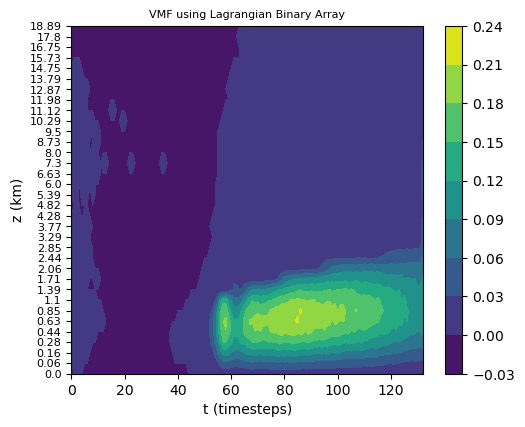

In [127]:
type='general'
# type='cloudy'

print('taking horizontal mean')
if type=='general':
    profile_array=profile_array_VMF_g.copy()
if type=='cloudy':
    profile_array=profile_array_VMF_c.copy()

profile_array=np.mean(profile_array,axis=(2,3))


import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np

fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, figure=fig)

######
cmap1 = plt.cm.viridis
cmap2 = plt.cm.seismic 
n_levels=29
######

# ######
# vmax_shared = np.max([np.max(profile_array_e), np.max(profile_array_d)])
# norm_shared = mcolors.Normalize(vmin=0, vmax=vmax_shared)
# ######

# First subplot: VMF
########################################
ax1 = fig.add_subplot(gs[0, 0])
# contour1 = ax1.contourf(profile_array_e.T, cmap=cmap1)
contour1 = ax1.contourf(profile_array.T, cmap=cmap1)
cbar1=fig.colorbar(contour1, ax=ax1)
apply_scientific_notation_colorbar([cbar1])
Nz = len(data['zh'])
ax1.set_yticks(np.arange(Nz))
new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
ax1.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
ax1.set_ylabel('z (km)');ax1.set_xlabel('t (timesteps)')
ax1.set_title('VMF using Lagrangian Binary Array',fontsize=8)

# #FIXING TICKS
# ax3.set_yticks(np.arange(Nz))
# new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
# ax3.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
# ax3.set_ylabel('z (km)');ax3.set_xlabel('t (timesteps)')
# ax3.set_title('Entrainment - Detrainment')

# #FIXING SCIENTIFIC NOTATION
# from matplotlib.ticker import ScalarFormatter
# formatter = ScalarFormatter(useMathText=True)
# formatter.set_powerlimits((-2, 2))  # Adjust the range for scientific notation
# for cbar in (cbar1,cbar2, cbar3):  # These must be Colorbar instances
#     cbar.formatter = formatter
#     cbar.update_ticks()

# Display the plot
plt.tight_layout()

Text(0.5, 0, 'Vertical Mass Flux, M(z) $(kg m^{-2} s^{-1})$')

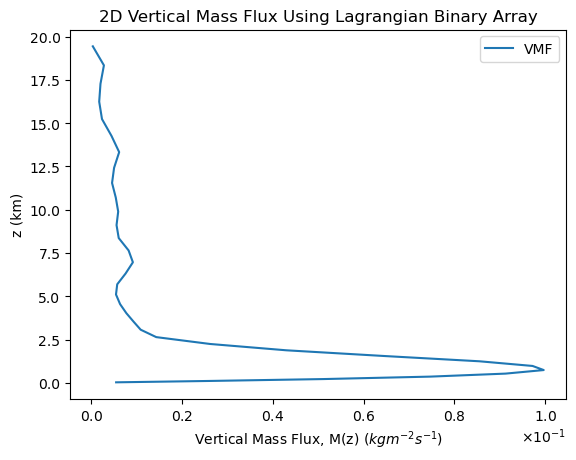

In [128]:
plt.plot(np.mean(profile_array,axis=(0)),data['zh'],label='VMF')

plt.legend(); plt.title('2D Vertical Mass Flux Using Lagrangian Binary Array')

from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))
plt.gca().xaxis.set_major_formatter(formatter)

plt.ylabel('z (km)');plt.xlabel('Vertical Mass Flux, M(z) ' + r'$(kg m^{-2} s^{-1})$')

# #COMPARING MAXIMUM WITH ROMPS 2012
# (1.4e-2)/(4e-3)

In [131]:
#TESTING HIGH

A=A_c.copy()
A=A_c_Processed.copy()

#Investigating high VMF vs low VMF Calculation
mask=np.where(profile_array_VMF_c>=1)
t,z,y,x=mask
i=0
(t,z,y,x)=t[i],z[i],y[i],x[i]
index=(t,z,y,x)
print(f'investigating VMF calculation at index {index}')
print(f'VMF = {profile_array_VMF_c[index]}\n')

# checking A 
cond0=T[t]==t
cond1=Z[t]==z
cond2=Y[t]==y
cond3=X[t]==x
mask=np.where(cond0&cond2&cond3)
print(f'all parcels in {t,z,y,x} include: {mask}\n')

print(f'A of each parcel: {A[t,mask]}')
print(f'W of each parcel: {W[t,mask]}')
print(f'A*W of each parcel: {A[t,mask]*W[t,mask]}\n')

print(f'Sum of A*W of each parcel: {np.sum(A[t,mask]*W[t,mask])}\n')

dz=(data['zf'][z+1]-data['zf'][z]).item()*1000
print(f'dz={dz}')
dm=1e9; const=dm/(dx*dy*dz) 
print(f'VMF constant = 1e9/200e3/512e3/{dz:.0f} = {const}')

print(f'Sum of A*W of each parcel: {np.sum(A[t,mask]*W[t,mask])}\n')

print(f'Sum of const A*W of each parcel: {const*np.sum(A[t,mask]*W[t,mask])}\n')


investigating VMF calculation at index (49, 7, 22, 138)
VMF = 1.7759743989701768

all parcels in (49, 7, 22, 138) include: (array([ 25936,  92064,  92351, 108590, 150348, 234997, 287844, 332550,
       350867, 372894, 451419, 646627, 761680, 766512]),)

A of each parcel: [[0 0 0 0 0 0 0 1 0 0 0 0 0 0]]
W of each parcel: [[-1.3368854e-02  1.3365687e-04 -1.2559212e-02  7.9613375e-03
  -1.6148474e-02  3.3635616e-02 -1.2559212e-02  5.0693637e-01
  -1.6148474e-02  7.9613375e-03  3.3635616e-02  1.1477892e-03
  -1.2559212e-02  4.0827697e-04]]
A*W of each parcel: [[-0.          0.         -0.          0.         -0.          0.
  -0.          0.50693637 -0.          0.          0.          0.
  -0.          0.        ]]

Sum of A*W of each parcel: 0.5069363713264465

dz=285.2531671524048
VMF constant = 1e9/200e3/512e3/285 = 3.50565783364544
Sum of A*W of each parcel: 0.5069363713264465

Sum of const A*W of each parcel: 1.777145461300351



In [132]:
#OLD TEST
# dz=285.2531671524048
# dy=1000;dx=1000
# Np=mask[0].shape[0]

# dm=data['rho'].isel(time=t,zh=z,yh=y,xh=x).item()*dz*dy*dx/Np
# print(f'fixed dm = {dm}')

# const=dm/(dx*dy*dz) 
# print(f'==> fixed const = {const}')

# print(f'==> Sum of const A*W of each parcel: {const*np.sum(A[t,mask]*W[t,mask])}\n')

In [120]:
#TESTING LOW
#Investigating high VMF vs low VMF Calculation

A=A_c.copy()
A=A_c_Processed.copy()

#Investigating high VMF vs low VMF Calculation
cond1=(profile_array_VMF_c<1.4e-2)
cond2=(profile_array_VMF_c>1.2e-2)
mask=np.where(cond1&cond2)

t,z,y,x=mask
i=0
(t,z,y,x)=t[i],z[i],y[i],x[i]
index=(t,z,y,x)
print(f'investigating VMF calculation at index {index}')
print(f'VMF = {profile_array_VMF_c[index]}\n')

# checking A 
cond0=T[t]==t
cond1=Z[t]==z
cond2=Y[t]==y
cond3=X[t]==x
mask=np.where(cond0&cond2&cond3)
print(f'all parcels in {t,z,y,x} include: {mask}\n')

print(f'A of each parcel: {A[t,mask]}')
print(f'W of each parcel: {W[t,mask]}')
print(f'A*W of each parcel: {A[t,mask]*W[t,mask]}\n')

print(f'Sum of A*W of each parcel: {np.sum(A[t,mask]*W[t,mask])}\n')

dz=(data['zf'][z+1]-data['zf'][z]).item()*1000
print(f'dz={dz}')
dm=1e9; const=dm/(dx*dy*dz)  
print(f'VMF constant = 1e9/200e3/512e3/{dz:.0f} = {const}')

print(f'Sum of A*W of each parcel: {np.sum(A[t,mask]*W[t,mask])}\n')

print(f'Sum of const A*W of each parcel: {const*np.sum(A[t,mask]*W[t,mask])}\n')


investigating VMF calculation at index (92, 23, 105, 184)
VMF = 0.013081713975169993

all parcels in (92, 23, 105, 184) include: (array([ 82591, 250005, 409445, 431378, 454362, 455830, 487216, 533709,
       653092]),)

A of each parcel: [[0 0 0 0 1 0 0 0 0]]
W of each parcel: [[-0.81523347  0.3306446   0.05851687 -0.18627039  0.01041397  0.3700656
   0.05851687  0.16747476 -0.07507861]]
A*W of each parcel: [[-0.          0.          0.         -0.          0.01041397  0.
   0.          0.         -0.        ]]

Sum of A*W of each parcel: 0.010413974523544312

dz=795.5465316772461
VMF constant = 1e9/200e3/512e3/796 = 1.2569974981748784
Sum of A*W of each parcel: 0.010413974523544312

Sum of const A*W of each parcel: 0.013090339922152121



In [133]:
# #OLD TEST
# dz=285.2531671524048
# dy=1000;dx=1000
# Np=mask[0].shape[0]

# dm=data['rho'].isel(time=t,zh=z,yh=y,xh=x).item()*dz*dy*dx/Np
# print(f'fixed dm = {dm}')

# const=dm/(dx*dy*dz) 
# print(f'==> fixed const = {const}')

# print(f'==> Sum of const A*W of each parcel: {const*np.sum(A[t,mask]*W[t,mask])}\n')

In [137]:
print(0.5*3.5)
print(0.01*1.25)

print(3.5/1.25)
print(0.5/0.01)

1.75
0.0125
2.8
50.0


In [53]:
# TESTING
PROCESSING=False
PROCESSING=True

if PROCESSING==False:
    dir3=dir+f'Project_Algorithms/Entrainment/3D_VMF_profiles_{res}_{Np_str}_5min.h5'
    # dir3=dir+f'Project_Algorithms/Entrainment/3D_VMF_profiles_{res}_{Np_str}_1min.h5'
if PROCESSING==True:
    dir3=dir+f'Project_Algorithms/Entrainment/3D_VMF_profiles_PREPROCESSING_{res}_{Np_str}_5min.h5'
    # dir3=dir+f'Project_Algorithms/Entrainment/3D_VMF_profiles_PREPROCESSING_{res}_{Np_str}_1min.h5'
with h5py.File(dir3, "r") as h5f:
    profile_array_VMF_g = h5f["profile_array_VMF_g"][:]
    profile_array_VMF_c = h5f["profile_array_VMF_c"][:]
def apply_constant(profile_array,apply):

    if apply==True:
        Nt=profile_array.shape[0]
        Nz=profile_array.shape[1]
    
        profile_array/=(dx*dy)
        for t in np.arange(Nt):
            profile_array[t]*=m_arr[t]
        for z in np.arange(Nz):
            dz=zf(z+1)-zf(z)
            profile_array[:,z]/=dz
    return profile_array

profile_array_VMF_g=apply_constant(profile_array_VMF_g,apply=True)
profile_array_VMF_c=apply_constant(profile_array_VMF_c,apply=True)

/tmp/ipykernel_136523/3071888983.py:19: RuntimeWarning: Mean of empty slice
  c_avg = np.nanmean(VMF_c_masked_data, axis=(0,2,3))


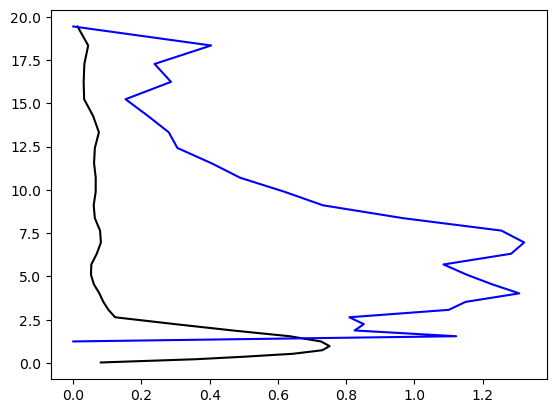

In [54]:
t_slice=slice(99,101)
w_data=data['winterp'].isel(time=t_slice).data
qc_plus_qi=data['qc'].isel(time=t_slice).data+data['qi'].isel(time=t_slice).data
w_thresh1=0.1
w_thresh2=0.5
qcqi_thresh=1e-6
mask1=(w_data>=w_thresh1)&(qc_plus_qi<qcqi_thresh)
mask2=(w_data>=w_thresh2)&(qc_plus_qi>=qcqi_thresh)



VMF_g_masked_data = profile_array_VMF_g[t_slice].copy()  # Copy the original data to preserve it
VMF_g_masked_data[~mask1] = np.nan

VMF_c_masked_data = profile_array_VMF_c[t_slice].copy()  # Copy the original data to preserve it
VMF_c_masked_data[~mask2] = np.nan

g_avg = np.nanmean(VMF_g_masked_data, axis=(0,2,3))
c_avg = np.nanmean(VMF_c_masked_data, axis=(0,2,3))

plt.plot(g_avg,data['zh'],color='black')
plt.plot(c_avg,data['zh'],color='blue')